In [20]:
import numpy as np
import pandas as pd
import torch
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import TimeSeriesSplit

# Section 01: Data Preparation

In [21]:
df_final =pd.read_csv("/kaggle/input/datasets/hansicooray/tournament-weighted-final-dataset/Tournament_weighted_Final_dataset.csv")

In [22]:
df_final.head(5)

,date,winner_id,winner_id_int,loser_id,loser_id_int,winner_rank,loser_rank,w_elo_before,l_elo_before,correct_prediction,rating_diff,Actual_mov,Prestige_Score,Round_Multiplier,Best_of
0,2010-04-11,P_104597,107,P_103752,54,34,58,1597.741983,1444.032115,True,153.709867,7,1.5,0.30,3
1,2010-04-11,P_103507,125,P_104542,130,16,10,1634.825632,1625.187680,True,9.637952,7,1.5,0.55,3
2,2010-04-11,P_104269,134,P_104925,128,12,2,1643.272725,1665.289038,False,-22.016313,5,1.5,0.85,3
3,2010-04-11,P_104745,90,P_103507,125,3,16,1715.555070,1647.741777,True,67.813294,6,1.5,0.70,3
4,2010-04-11,P_104745,90,P_103582,40,3,51,1705.550059,1568.707602,True,136.842456,5,1.5,0.55,3


In [23]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37958 entries, 0 to 37957
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                37958 non-null  object 
 1   winner_id           37958 non-null  object 
 2   winner_id_int       37958 non-null  int64  
 3   loser_id            37958 non-null  object 
 4   loser_id_int        37958 non-null  int64  
 5   winner_rank         37958 non-null  int64  
 6   loser_rank          37958 non-null  int64  
 7   w_elo_before        37958 non-null  float64
 8   l_elo_before        37958 non-null  float64
 9   correct_prediction  37958 non-null  bool   
 10  rating_diff         37958 non-null  float64
 11  Actual_mov          37958 non-null  int64  
 12  Prestige_Score      37958 non-null  float64
 13  Round_Multiplier    37958 non-null  float64
 14  Best_of             37958 non-null  int64  
dtypes: bool(1), float64(5), int64(6), object(3)
memory us

In [24]:
# chronological order
df_final['date'] = pd.to_datetime(df_final['date'])
df_final = df_final.sort_values('date').reset_index(drop=True)

In [25]:
# Time-Series split for training and testing.
split_idx = int(len(df_final) * 0.7)
df_train = df_final.iloc[:split_idx]
df_test = df_final.iloc[split_idx:]

In [26]:
df_train.describe()

,date,winner_id_int,loser_id_int,winner_rank,loser_rank,w_elo_before,l_elo_before,rating_diff,Actual_mov,Prestige_Score,Round_Multiplier,Best_of
count,26570,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000,26570.000000
mean,2015-02-20 06:29:01.332329472,284.947158,334.035529,76.061874,118.134964,1677.564475,1597.548052,80.016423,5.307452,1.411110,0.482896,3.472864
min,2010-04-11 00:00:00,0.000000,0.000000,1.000000,1.000000,1320.744698,1328.301738,-815.087317,1.000000,1.200000,0.250000,3.000000
25%,2012-07-26 06:00:00,78.000000,82.000000,17.000000,36.000000,1536.381197,1498.256666,-31.598730,3.000000,1.200000,0.300000,3.000000
50%,2015-03-06 00:00:00,134.000000,193.000000,43.000000,67.000000,1643.951154,1567.083908,63.655638,5.000000,1.200000,0.400000,3.000000
75%,2017-07-31 00:00:00,424.000000,500.000000,82.000000,115.000000,1779.734121,1671.220130,182.813037,7.000000,1.500000,0.650000,3.000000
max,2020-03-06 00:00:00,1310.000000,1313.000000,2091.000000,2159.000000,2378.984707,2380.692297,956.085497,18.000000,2.000000,1.000000,5.000000
std,NaN,301.267064,323.017814,133.604027,188.152554,182.012523,136.323085,179.146412,2.757322,0.298062,0.181557,0.849797


In [27]:
print(f"Training matches: {len(df_train)}")
print(f"Testing matches: {len(df_test)}")

Training matches: 26570
Testing matches: 11388


# Section 02 : Optimising Parameters

### Optimising Alpha and Beta

In [28]:
# Prepare data for curve fit - To find Alpha and Beta
x_data = df_train['rating_diff'].values
y_data = df_train['Actual_mov'].values

In [29]:
#Define MOVDA Function  to calculate E_MOV
def movda_function(dr, alpha, beta):
    return alpha * np.tanh(beta * dr)

In [30]:
# Curve fit using po intial values - 10 aloha and 1 beta
# popt - parameter optimal-> popt[0] - alpha, popt[1] -beta
# pcov - Parameter covariance 
popt, pcov = curve_fit(movda_function, x_data, y_data, p0=[10.0, 1.0])

In [31]:
#Get values for alpha and beta
alpha_opt, beta_opt = popt
print("Optimal value for alpha is :", alpha_opt)
print("Optimal value for beta is :",  beta_opt )

Optimal value for alpha is : 6.0115065740403235
Optimal value for beta is : 0.0024355369431429846


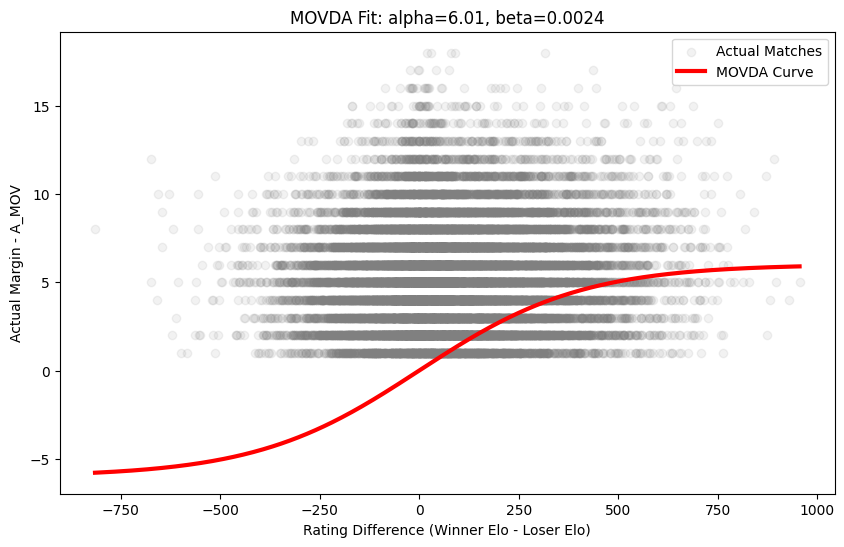

In [32]:
# VISUALISATIONS
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.1, color='gray', label='Actual Matches')

# Create a smooth line for the prediction curve
dr_range = np.linspace(x_data.min(), x_data.max(), 500)
expected_mov = movda_function(dr_range, alpha_opt, beta_opt)

plt.plot(dr_range, expected_mov, color='red', linewidth=3, label='MOVDA Curve')
plt.title(f'MOVDA Fit: alpha={alpha_opt:.2f}, beta={beta_opt:.4f}')
plt.xlabel('Rating Difference (Winner Elo - Loser Elo)')
plt.ylabel('Actual Margin - A_MOV')
plt.legend()
plt.show()

### Optimising Lamda

In [33]:
#Define the Grid Search Range
lambda_range = np.arange(0.1, 3.1, 0.1)

In [34]:
# Variables to track the best performing lambda
initial_elo = 1500 
lamda_best = 0
max_accuracy = 0
grid_search_results = []
k_factor =32

In [35]:
# Outer loop to iterate through each lambda in the given range
for current_lamda in lambda_range:
    player_elos = {} # to reset ratings for each lambda test
    correct_predictions = 0
    
    # Inner loop to run the model (std + movda Elo)
    for index, row in df_train.iterrows():
        w_id = row['winner_id_int']
        l_id = row['loser_id_int']
        actual_mov = row['Actual_mov']
        
        w_elo_before = player_elos.get(w_id, initial_elo)
        l_elo_before = player_elos.get(l_id, initial_elo)
        
        if w_elo_before > l_elo_before:
            correct_predictions += 1
            
        dr = w_elo_before - l_elo_before # Elo difference 
        
        # Standard Elo part
        std_elo = 1 / (1 + 10**(-dr / 400))
        
        # MOVDA part
        expected_mov = alpha_opt * np.tanh(beta_opt * dr)
        
        # MOVDA Update Rule using the current lambda from the grid search
        delta_mov = actual_mov - expected_mov
        rating_change = (k_factor * (1 - std_elo)) + (current_lamda * delta_mov)
        
        # Player rating updates
        player_elos[w_id] = w_elo_before + rating_change
        player_elos[l_id] = l_elo_before - rating_change
    
    # 5. Evaluate this lambda's accuracy
    accuracy = (correct_predictions / len(df_train)) * 100
    grid_search_results.append((current_lamda, accuracy))
    
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        lamda_best = current_lamda

print(f"Best Lamda: {lamda_best:.1f}")
print(f"Maximum Accuracy: {max_accuracy:.2f}%")

Best Lamda: 2.9
Maximum Accuracy: 66.53%


# Section 02 - Implementing Models

In [36]:
#Parameters
initial_elo = 1500 
alpha = alpha_opt
beta = beta_opt
k_base = 32
best_lamda = lamda_best

## Implementation of Model 01- Std Baseline Model

In [37]:
# Model 01- Standard Baseline Model
def run_model_01_engine(data, initial_elos=None):
    player_elos = initial_elos.copy() if initial_elos is not None else {}
    results = []
    correct_predictions = 0
    brier_elements = []

    for index, row in data.iterrows():
        w_id = row['winner_id_int']
        l_id = row['loser_id_int']
        
        # Get current ratings
        w_elo_before = player_elos.get(w_id, initial_elo)
        l_elo_before = player_elos.get(l_id, initial_elo)
        
        # Probability Calculation
        dr = w_elo_before - l_elo_before
        win_prob = 1 / (1 + 10**(-dr / 400))
        brier_elements.append((win_prob, 1)) 
        
        if w_elo_before > l_elo_before:
            correct_predictions += 1
        
        # Standard update rule 
        rating_change = k_base * (1 - win_prob)
        
        # Update rates of the players
        player_elos[w_id] = w_elo_before + rating_change
        player_elos[l_id] = l_elo_before - rating_change
        
        results.append({
            'date': row['date'],
            'win_prob': win_prob,
            'rating_change': rating_change
        })
        
    # Metrics
    accuracy = (correct_predictions / len(data)) * 100
    probs, outcomes = zip(*brier_elements)
    brier_score = brier_score_loss(outcomes, probs)
    
    return accuracy, brier_score, player_elos, pd.DataFrame(results)


In [38]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results_m01 = []

for fold, (train_index, test_index) in enumerate(tscv.split(df_test)):
    cv_train = df_final.iloc[train_index]
    cv_test = df_final.iloc[test_index]
    
    # Train
    _, _, trained_elos_m01, _ = run_model_01_engine(cv_train)
    
    # Test
    f_acc, f_brier, _, _ = run_model_01_engine(cv_test, trained_elos_m01)
    
    cv_results_m01.append({'acc': f_acc, 'brier': f_brier})
    print(f"Fold {fold+1}: Accuracy = {f_acc:.2f}% | Brier Score = {f_brier:.4f}")


mean_acc_m01 = np.mean([f['acc'] for f in cv_results_m01])
mean_brier_m01 = np.mean([f['brier'] for f in cv_results_m01])


print(f"MODEL 01 SUMMARY")
print(f"Final Mean Accuracy: {mean_acc_m01:.2f}%")
print(f"Final Mean Brier Score: {mean_brier_m01:.4f}")

Fold 1: Accuracy = 65.91% | Brier Score = 0.2079
Fold 2: Accuracy = 66.44% | Brier Score = 0.2037
Fold 3: Accuracy = 69.55% | Brier Score = 0.1928
Fold 4: Accuracy = 65.96% | Brier Score = 0.2093
Fold 5: Accuracy = 67.39% | Brier Score = 0.2038
MODEL 01 SUMMARY
Final Mean Accuracy: 67.05%
Final Mean Brier Score: 0.2035


### Implementation of Model 02- Std+MOVDA Elo

In [41]:
# Model 02 - Std Elo + MOVDA
def run_model_02_engine(data, initial_elos=None):
    """
    Executes STD Elo + MOVDA logic (No Tournament Weights).
    """
    player_elos = initial_elos.copy() if initial_elos is not None else {}
    results = []
    correct_predictions = 0
    brier_elements = []

    for index, row in data.iterrows():
        w_id = row['winner_id_int']
        l_id = row['loser_id_int']
        actual_mov = row['Actual_mov']
        
        # Get current ratings
        w_elo_before = player_elos.get(w_id, initial_elo)
        l_elo_before = player_elos.get(l_id, initial_elo)
        
        # Std Component
        dr = w_elo_before - l_elo_before
        win_prob = 1 / (1 + 10**(-dr / 400))
        brier_elements.append((win_prob)) 
        
        if w_elo_before > l_elo_before:
            correct_predictions += 1
        
        # E_MOV
        k_val = k_base 
        expected_mov = alpha * np.tanh(beta * dr)
        
        # Update rule -  Std base + MOVDA
        delta_mov = actual_mov - expected_mov
        rating_change = (k_val * (1 - win_prob)) + (best_lamda * delta_mov)
        
        # Update ratings
        player_elos[w_id] = w_elo_before + rating_change
        player_elos[l_id] = l_elo_before - rating_change
        
        results.append({
            'date': row['date'],
            'win_prob': win_prob,
            'rating_change': rating_change
        })
        
    # Metrics
    accuracy = (correct_predictions / len(data)) * 100
    outcomes = np.ones(len(brier_elements)) 
    brier_score = brier_score_loss(outcomes, brier_elements)
    
    return accuracy, brier_score, player_elos, pd.DataFrame(results)

In [42]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results_m02 = []

for fold, (train_index, test_index) in enumerate(tscv.split(df_test)):
    cv_train = df_final.iloc[train_index]
    cv_test = df_final.iloc[test_index]
    
    # Train the Model 02
    _, _, trained_elos_m02, _ = run_model_02_engine(cv_train)
    
    # Test the Model 02
    f_acc, f_brier, _, _ = run_model_02_engine(cv_test, trained_elos_m02)
    
    cv_results_m02.append({'acc': f_acc, 'brier': f_brier})
    print(f"Fold {fold+1}: Accuracy = {f_acc:.2f}% | Brier Score = {f_brier:.4f}")

mean_acc_m02 = np.mean([f['acc'] for f in cv_results_m02])
mean_brier_m02 = np.mean([f['brier'] for f in cv_results_m02])


print(f"MODEL 02 SUMMARY")
print(f"Final Mean Accuracy: {mean_acc_m02:.2f}%")
print(f"Final Mean Brier Score: {mean_brier_m02:.4f}")

Fold 1: Accuracy = 67.28% | Brier Score = 0.2070
Fold 2: Accuracy = 66.75% | Brier Score = 0.2050
Fold 3: Accuracy = 70.02% | Brier Score = 0.1950
Fold 4: Accuracy = 66.02% | Brier Score = 0.2123
Fold 5: Accuracy = 68.07% | Brier Score = 0.2062
MODEL 02 SUMMARY
Final Mean Accuracy: 67.63%
Final Mean Brier Score: 0.2051


### Implementation of Model 03 - Std+MOVDA+Tournament Weighting Elo

In [45]:
# MODEL 03 
def run_model_03_engine(data, initial_elos=None):
    player_elos = initial_elos.copy() if initial_elos is not None else {}
    results = []
    correct_predictions = 0
    brier_elements = []

    for index, row in data.iterrows():
        w_id = row['winner_id_int']
        l_id = row['loser_id_int']
        actual_mov = row['Actual_mov']
        
        # Get current ratings
        w_elo_before = player_elos.get(w_id, initial_elo)
        l_elo_before = player_elos.get(l_id, initial_elo)
        
        # Std Component
        dr = w_elo_before - l_elo_before
        win_prob = 1 / (1 + 10**(-dr / 400))
        # Brier components(prob, outcome)
        brier_elements.append((win_prob, 1)) 
        
        if w_elo_before > l_elo_before:
            correct_predictions += 1
        
        # Tournament weighted K-Factor
        weighted_k = k_base * row['Prestige_Score'] * row['Round_Multiplier']
        
        expected_mov = (alpha * np.tanh(beta * dr)) 
        
        # Update rule of model 03
        delta_mov = actual_mov - expected_mov
        rating_change = (weighted_k * (1 - win_prob)) + (best_lamda * delta_mov)
        
        # Update player ratings
        player_elos[w_id] = w_elo_before + rating_change
        player_elos[l_id] = l_elo_before - rating_change
        
        results.append({
            'date': row['date'],
            'win_prob': win_prob,
            'rating_change': rating_change,
            'w_elo_after': player_elos[w_id],
            'l_elo_after': player_elos[l_id]
        })
        
    # Calculate performance metrics
    accuracy = (correct_predictions / len(data)) * 100
    probs, outcomes = zip(*brier_elements)
    brier_score = brier_score_loss(outcomes, probs)
    
    return accuracy, brier_score, player_elos, pd.DataFrame(results)

In [46]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results_m03 = []

for fold, (train_index, test_index) in enumerate(tscv.split(df_test)):
    cv_train = df_final.iloc[train_index]
    cv_test = df_final.iloc[test_index]
    
    # Train the Model 02
    _, _, trained_elos_m03, _ = run_model_03_engine(cv_train)
    
    # Test the Model 02
    f_acc, f_brier, _, _ = run_model_03_engine(cv_test, trained_elos_m03)
    
    cv_results_m03.append({'acc': f_acc, 'brier': f_brier})
    print(f"Fold {fold+1}: Accuracy = {f_acc:.2f}% | Brier Score = {f_brier:.4f}")

mean_acc_m03 = np.mean([f['acc'] for f in cv_results_m03])
mean_brier_m03 = np.mean([f['brier'] for f in cv_results_m03])


print(f"MODEL 03 SUMMARY")
print(f"Final Mean Accuracy: {mean_acc_m03:.2f}%")
print(f"Final Mean Brier Score: {mean_brier_m03:.4f}")

Fold 1: Accuracy = 66.75% | Brier Score = 0.2071
Fold 2: Accuracy = 66.44% | Brier Score = 0.2055
Fold 3: Accuracy = 70.28% | Brier Score = 0.1942
Fold 4: Accuracy = 65.91% | Brier Score = 0.2112
Fold 5: Accuracy = 68.07% | Brier Score = 0.2054
MODEL 03 SUMMARY
Final Mean Accuracy: 67.49%
Final Mean Brier Score: 0.2047


### Comparison of Brier Score

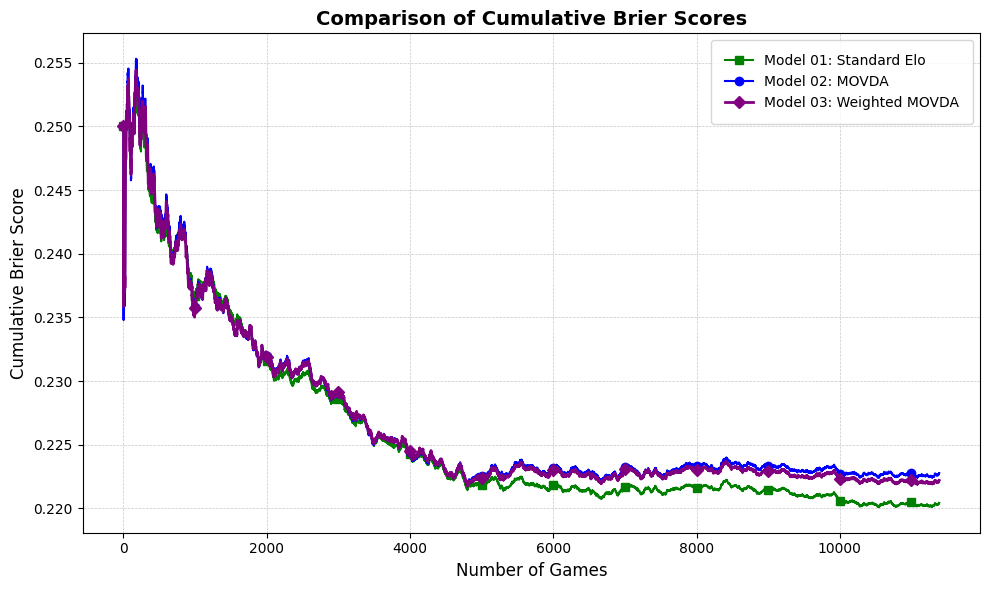

In [52]:
import matplotlib.pyplot as plt
import numpy as np

def get_cumulative_brier(results_df):
    probs = results_df['win_prob'].values
    errors = (probs - 1)**2
    return np.cumsum(errors) / np.arange(1, len(errors) + 1)

# Run the models
_, _, _, res_m1 = run_model_01_engine(df_test)
_, _, _, res_m2 = run_model_02_engine(df_test)
_, _, _, res_m3 = run_model_03_engine(df_test)

# Calculate the lines
line1 = get_cumulative_brier(res_m1)
line2 = get_cumulative_brier(res_m2)
line3 = get_cumulative_brier(res_m3)

# Visualisation
plt.figure(figsize=(10, 6), facecolor='white')

x_axis = np.arange(len(line1))
mark_interval = 1000 

plt.plot(x_axis, line1, label='Model 01: Standard Elo', color='green', 
         marker='s', markevery=mark_interval, markersize=6, linewidth=1.5)

plt.plot(x_axis, line2, label='Model 02: MOVDA', color='blue', 
         marker='o', markevery=mark_interval, markersize=6, linewidth=1.5)

plt.plot(x_axis, line3, label='Model 03: Weighted MOVDA', color='purple', 
         marker='D', markevery=mark_interval, markersize=6, linewidth=2.0)


plt.title('Comparison of Cumulative Brier Scores', fontsize=14, fontweight='bold')
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Cumulative Brier Score', fontsize=12)


all_values = np.concatenate([line1, line2, line3])
plt.ylim(all_values.min() - 0.002, all_values.max() + 0.002)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', frameon=True, borderpad=1)

plt.tight_layout()
plt.show()